<a href="https://colab.research.google.com/github/yousuf-24/Machine-Learning-Codes/blob/main/HW_ML_Lab2(ASI).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
df = pd.read_csv('/content/drive/MyDrive/ML lab file/ Film Genre Stats.csv')
df.head()

,index,Genre,Year,Movies Released,Gross,Tickets Sold,Inflation-Adjusted Gross,Top Movie,Top Movie Gross (That Year),Top Movie Inflation-Adjusted Gross (That Year)
0,0,Adventure,1995,29,771507571,177358047,1590901682,Toy Story,150148222,3.096160e+08
1,1,Adventure,1996,34,1290490033,291966054,2618935504,Independence Day,306169255,6.213435e+08
2,2,Adventure,1997,23,881902843,192135684,1723457085,Men in Black,250650052,4.898324e+08
3,3,Adventure,1998,29,1614467732,344236174,3087798481,Armageddon,201578182,3.855344e+08
4,4,Adventure,1999,27,1612432107,317407880,2847148684,Star Wars Ep. I: The Phantom Menace,430443350,7.600545e+08


In [30]:
df.tail()

,index,Genre,Year,Movies Released,Gross,Tickets Sold,Inflation-Adjusted Gross,Top Movie,Top Movie Gross (That Year),Top Movie Inflation-Adjusted Gross (That Year)
295,295,Multiple Genres,2017,5,4614134,514394,4614114,2017 Oscar Shorts,2835355,2.835343e+06
296,296,Multiple Genres,2018,3,4787450,533717,4787441,2018 Oscar Shorts,3508777,3.508770e+06
297,297,Reality,2014,1,16826,2059,18469,The Principle,16826,1.846900e+04
298,298,Reality,2015,3,604870,71751,643606,Benpao Ba! Xiongdi,309297,3.291044e+05
299,299,Reality,2018,1,2027,225,2018,The Cage Fighter,2027,2.018000e+03


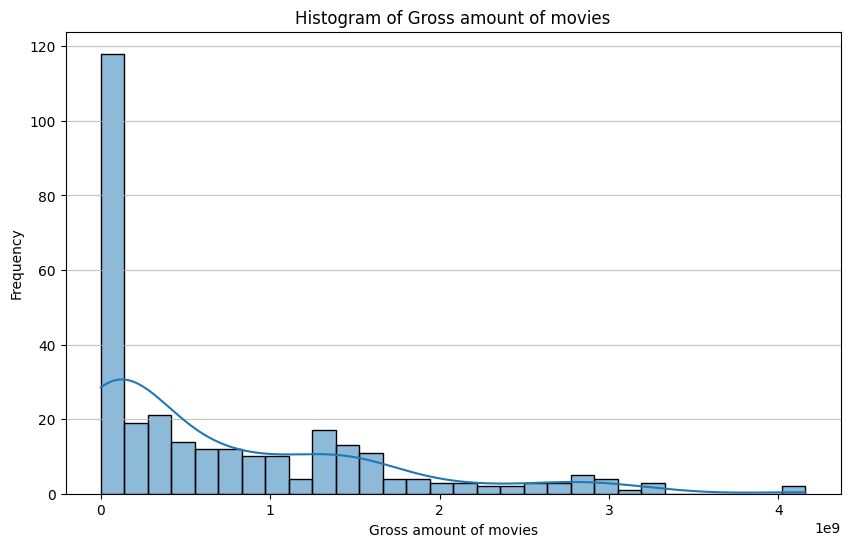

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Gross'], bins=30, kde=True)
plt.title('Histogram of Gross amount of movies')
plt.xlabel('Gross amount of movies')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

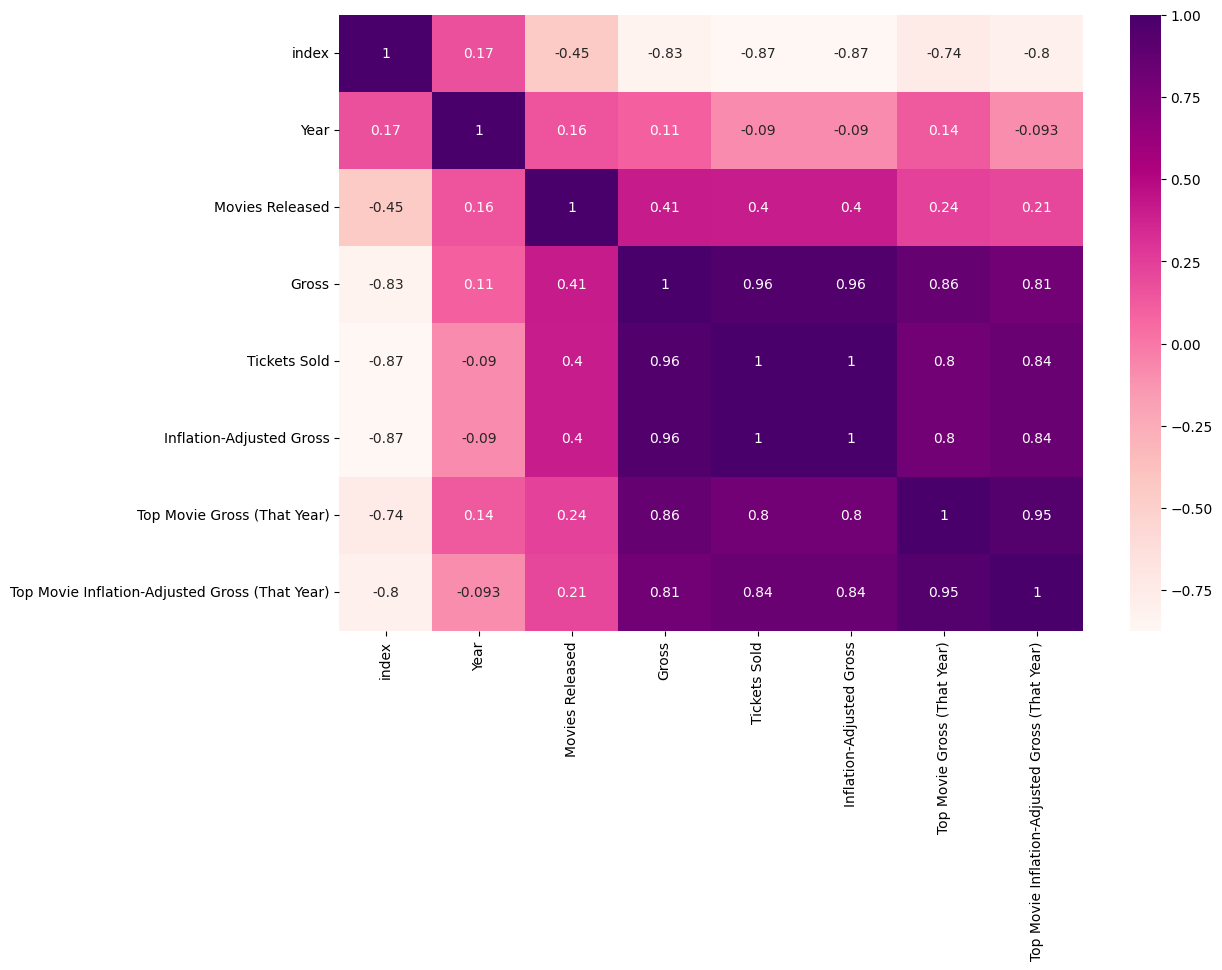

In [32]:
plt.figure(figsize = (12,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(method= 'pearson'), annot = True, cmap = 'RdPu')
plt.show()

In [33]:
x = df.drop(['Gross'], axis=1).select_dtypes(include=[np.number])
y = df['Gross']

In [34]:
from sklearn.preprocessing import MinMaxScaler
Scaler = MinMaxScaler(feature_range=(0,1))
x_Scaled = Scaler.fit_transform(x)

In [35]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_Scaled, y, test_size = 0.2, random_state = 3)

In [36]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(x_train, y_train)

LinearRegression()

In [37]:
print('Intercept:', lin_model.intercept_)
print('Coefficients:', lin_model.coef_)

Intercept: 53659015.319690466
Coefficients: [-1.08278690e+08  5.19072667e+07 -4.04096351e+07  1.09798169e+17
 -1.09798166e+17  3.62124997e+09 -3.04993056e+09]


In [38]:
y_pred = lin_model.predict(x_test)
print(y_pred[:5])

[ 1.39698462e+09 -3.87716714e+07  6.49367063e+07 -3.73276424e+07
  1.47535045e+09]


In [39]:
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score

In [40]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R2 SCORE:', r2)

MAE: 65634013.406729765
MSE: 9327294790888520.0
RMSE: 96577920.82504427
R2 SCORE: 0.988009266919759
